In [1]:
import sys
!{sys.executable} -m pip install scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Descargamos el German Credit Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columnas = [
    'estado_cuenta', 'duracion', 'historial_credito', 'proposito', 
    'monto', 'ahorros', 'empleo', 'tasa_cuota', 'estado_civil',
    'deudores', 'residencia', 'propiedad', 'edad', 'otros_planes',
    'vivienda', 'creditos_existentes', 'trabajo', 'dependientes',
    'telefono', 'trabajador_extranjero', 'riesgo'
]

df = pd.read_csv(url, sep=' ', names=columnas)

# Convertimos variable objetivo: 1=buen cliente, 0=mal cliente
df['riesgo'] = df['riesgo'].map({1: 1, 2: 0})

print(f"Dataset cargado: {df.shape}")
print(f"\nDistribución de riesgo:")
print(df['riesgo'].value_counts())

Dataset cargado: (1000, 21)

Distribución de riesgo:
riesgo
1    700
0    300
Name: count, dtype: int64


In [4]:
# Exploración básica
print("Primeras filas:")
print(df.head())
print(f"\nValores nulos:")
print(df.isnull().sum().sum())
print(f"\nEstadísticas de variables numéricas:")
print(df[['edad', 'monto', 'duracion']].describe())

Primeras filas:
  estado_cuenta  duracion historial_credito proposito  monto ahorros empleo  \
0           A11         6               A34       A43   1169     A65    A75   
1           A12        48               A32       A43   5951     A61    A73   
2           A14        12               A34       A46   2096     A61    A74   
3           A11        42               A32       A42   7882     A61    A74   
4           A11        24               A33       A40   4870     A61    A73   

   tasa_cuota estado_civil deudores  ...  propiedad edad  otros_planes  \
0           4          A93     A101  ...       A121   67          A143   
1           2          A92     A101  ...       A121   22          A143   
2           2          A93     A101  ...       A121   49          A143   
3           2          A93     A103  ...       A122   45          A143   
4           3          A93     A101  ...       A124   53          A143   

  vivienda creditos_existentes  trabajo dependientes  telefono  

In [5]:
# Identificamos columnas categóricas
categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f"Columnas categóricas: {categoricas}")

# Aplicamos One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"\nColumnas originales: {df.shape[1]}")
print(f"Columnas después del encoding: {df_encoded.shape[1]}")

Columnas categóricas: ['estado_cuenta', 'historial_credito', 'proposito', 'ahorros', 'empleo', 'estado_civil', 'deudores', 'propiedad', 'otros_planes', 'vivienda', 'trabajo', 'telefono', 'trabajador_extranjero']

Columnas originales: 21
Columnas después del encoding: 49


/var/folders/x8/d3v9j6g13818cd5lt_ks8jkr0000gn/T/ipykernel_36955/266561032.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object']).columns.tolist()


In [6]:
# Separamos X (predictoras) y y (objetivo)
X = df_encoded.drop('riesgo', axis=1)
y = df_encoded['riesgo']

# Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

Datos de entrenamiento: (800, 48)
Datos de prueba: (200, 48)


In [7]:
# Construimos el Random Forest
modelo = RandomForestClassifier(
    n_estimators=100,    # 100 árboles
    random_state=42,     # Reproducibilidad
    class_weight='balanced'  # Corrige el desbalance 70/30
)

# Entrenamos
modelo.fit(X_train, y_train)

# Predecimos
y_pred = modelo.predict(X_test)

print("✅ Modelo entrenado")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred, 
      target_names=['Mal cliente', 'Buen cliente']))

✅ Modelo entrenado

Reporte de clasificación:
              precision    recall  f1-score   support

 Mal cliente       0.77      0.34      0.47        59
Buen cliente       0.78      0.96      0.86       141

    accuracy                           0.78       200
   macro avg       0.77      0.65      0.66       200
weighted avg       0.77      0.78      0.74       200



In [8]:
# Obtenemos probabilidades en lugar de clasificación directa
y_prob = modelo.predict_proba(X_test)[:, 1]

# Bajamos el umbral a 0.40
umbral = 0.40
y_pred_umbral = (y_prob >= umbral).astype(int)

print(f"Reporte con umbral {umbral}:")
print(classification_report(y_test, y_pred_umbral,
      target_names=['Mal cliente', 'Buen cliente']))

Reporte con umbral 0.4:
              precision    recall  f1-score   support

 Mal cliente       0.83      0.17      0.28        59
Buen cliente       0.74      0.99      0.84       141

    accuracy                           0.74       200
   macro avg       0.79      0.58      0.56       200
weighted avg       0.77      0.74      0.68       200



In [9]:
# Probabilidad de ser MAL cliente (clase 0)
y_prob_malo = modelo.predict_proba(X_test)[:, 0]

# Si probabilidad de ser malo > 40%, clasificamos como malo
umbral = 0.40
y_pred_umbral = (y_prob_malo < umbral).astype(int)

print(f"Reporte con umbral {umbral}:")
print(classification_report(y_test, y_pred_umbral,
      target_names=['Mal cliente', 'Buen cliente']))

Reporte con umbral 0.4:
              precision    recall  f1-score   support

 Mal cliente       0.58      0.53      0.55        59
Buen cliente       0.81      0.84      0.83       141

    accuracy                           0.75       200
   macro avg       0.70      0.68      0.69       200
weighted avg       0.74      0.75      0.75       200



In [10]:
# Probamos varios umbrales para encontrar el óptimo
umbrales = [0.30, 0.25, 0.20, 0.15]

for umbral in umbrales:
    y_pred_u = (y_prob_malo < umbral).astype(int)
    reporte = classification_report(y_test, y_pred_u, 
                output_dict=True, 
                target_names=['Mal cliente', 'Buen cliente'])
    
    recall_malo = reporte['Mal cliente']['recall']
    precision_malo = reporte['Mal cliente']['precision']
    accuracy = reporte['accuracy']
    
    print(f"Umbral {umbral} → Recall malo: {recall_malo:.2f} | "
          f"Precision malo: {precision_malo:.2f} | "
          f"Accuracy: {accuracy:.2f}")

Umbral 0.3 → Recall malo: 0.80 | Precision malo: 0.49 | Accuracy: 0.69
Umbral 0.25 → Recall malo: 0.88 | Precision malo: 0.43 | Accuracy: 0.62
Umbral 0.2 → Recall malo: 0.95 | Precision malo: 0.40 | Accuracy: 0.56
Umbral 0.15 → Recall malo: 0.97 | Precision malo: 0.35 | Accuracy: 0.46


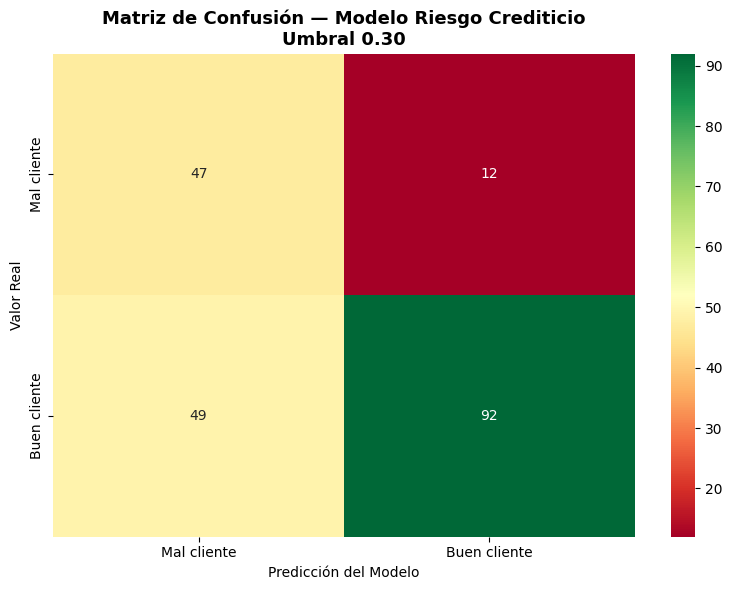

In [11]:
umbral_final = 0.30
y_pred_final = (y_prob_malo < umbral_final).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Mal cliente', 'Buen cliente'],
            yticklabels=['Mal cliente', 'Buen cliente'])

ax.set_title('Matriz de Confusión — Modelo Riesgo Crediticio\nUmbral 0.30', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Valor Real')
ax.set_xlabel('Predicción del Modelo')

plt.tight_layout()
plt.show()

/var/folders/x8/d3v9j6g13818cd5lt_ks8jkr0000gn/T/ipykernel_36955/2007729318.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias,


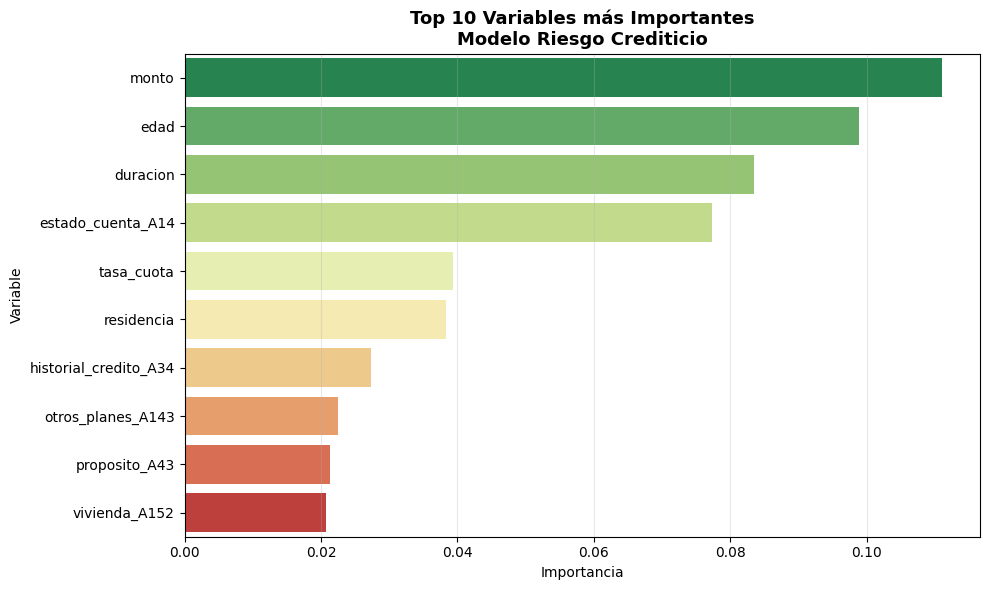

In [12]:
# Importancia de variables
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias, 
            palette='RdYlGn_r')

ax.set_title('Top 10 Variables más Importantes\nModelo Riesgo Crediticio', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
